### Given slippage model outputs, how do we assess performance?

Gathering all replication-level outputs into one df for analysis

In [5]:
base_path = '/Users/robinms1/Library/CloudStorage/Box-Box/NHH15 - USDA APHIS EDISON/05 PPQ Engagement/PPQ RBS Data (Folder shared with APHIS)/APL Created Data Related Items/Model_Testing/Official_Results/'
experiments = ['Baseline', 'Model 1', 'Model 2', 'Model 3']

cols_of_interest = ['inspection_number',
       'risk_unit_id', 'num_sample_units', 'num_plants', 'infected_plants',
       'is_infected', 'is_detected', 'missed', 'was_inspected',
       'inspected_sample_units']

def gather_experiment_data(filepath, experiments, cols_of_interest=cols_of_interest):    
    '''
    Collect experiment data in one pandas DataFrame, with tags for experiment and replication number. Used to 
    gather slippage data for analysis
    
    '''
    results_stack = []
    # for each experiment:
    for exp in experiments:

        exp_path = base_path + exp + '/Replications/'
        # Get all replications - assuming structure remains the same, no other files
        reps = os.listdir(exp_path)

        # for each replication:
        for rep in reps:
            # Collect all relevant info
            df_rep = pd.read_csv(exp_path + rep + '/synthetic_commodity_line_results_data.csv', usecols=cols_of_interest)

            # assuming same naming conventions (e.g., rep_0, rep_1, ...)
            df_rep['replication'] = rep
            df_rep['experiment'] = exp


            results_stack.append(df_rep)

    df_results = pd.concat(results_stack)
    
    return df_results

df_results = gather_experiment_data(base_path, experiments)

In [6]:
df_results
# TODO: commodity-line level slippage? (missed=True)

,inspection_number,risk_unit_id,num_sample_units,num_plants,infected_plants,is_infected,is_detected,missed,was_inspected,inspected_sample_units,replication,experiment
0,INS_0,INS_0_risk_unit_1,2,1000,0,False,False,False,False,0,rep_43,Baseline
1,INS_0,INS_0_risk_unit_1,70,2800,0,False,False,False,True,6,rep_43,Baseline
2,INS_0,INS_0_risk_unit_1,7,58800,0,False,False,False,True,1,rep_43,Baseline
3,INS_0,INS_0_risk_unit_1,70,58800,0,False,False,False,True,6,rep_43,Baseline
4,INS_0,INS_0_risk_unit_1,7,7600,0,False,False,False,False,0,rep_43,Baseline
...,...,...,...,...,...,...,...,...,...,...,...,...
30108,INS_998,INS_998_risk_unit_3,1,1,0,False,False,False,True,1,rep_36,Model 3
30109,INS_998,INS_998_risk_unit_3,1,1,0,False,False,False,True,1,rep_36,Model 3
30110,INS_998,INS_998_risk_unit_3,1,21,0,False,False,False,True,1,rep_36,Model 3
30111,INS_998,INS_998_risk_unit_3,1,3,0,False,False,False,True,1,rep_36,Model 3


In [194]:
# Confirming these are all the same counts as expected
df_results['replication'].value_counts().head()

replication
rep_43    120452
rep_48    120452
rep_22    120452
rep_49    120452
rep_47    120452
Name: count, dtype: int64

In [8]:
# Confirming these are all the same counts as expected
df_results['experiment'].value_counts()

experiment
Baseline    1505650
Model 1     1505650
Model 2     1505650
Model 3     1505650
Name: count, dtype: int64

In [11]:
df = df_results.copy()

df['num_plants_slipped'] = df['missed'].astype(int) * df['infected_plants']
df['prop_inspected'] = df['inspected_sample_units'] / df['num_plants']

total_slippage = df.groupby(['experiment', 'replication'])['num_plants_slipped'].sum().reset_index()

n_inspected_sample_units = df.groupby(['experiment', 'replication', 'inspection_number'])['inspected_sample_units'].sum().reset_index()
mean_inspected_sample_units = n_inspected_sample_units.groupby(['experiment', 'replication'])['inspected_sample_units'].mean().reset_index()


In [12]:
total_slippage

,experiment,replication,num_plants_slipped
0,Baseline,rep_0,941
1,Baseline,rep_1,546
2,Baseline,rep_10,349
3,Baseline,rep_11,352
4,Baseline,rep_12,289
...,...,...,...
195,Model 3,rep_5,370
196,Model 3,rep_6,89
197,Model 3,rep_7,232
198,Model 3,rep_8,8


In [29]:
# Some outliers - rep 37 & 49
total_slippage.sort_values('num_plants_slipped').tail(15)

,experiment,replication,num_plants_slipped
40,Baseline,rep_45,2318
12,Baseline,rep_2,2546
62,Model 1,rep_2,2965
34,Baseline,rep_4,3223
84,Model 1,rep_4,3273
184,Model 3,rep_4,3379
134,Model 2,rep_4,3664
81,Model 1,rep_37,15584
131,Model 2,rep_37,17126
31,Baseline,rep_37,17476


/Users/robinms1/anaconda3/lib/python3.10/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


Text(0.5, 1.0, 'Replication-Level Plant Slippage')

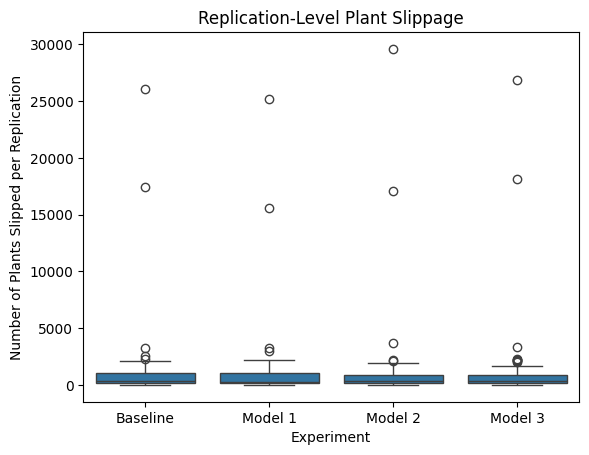

In [84]:
sns.boxplot(total_slippage, x='experiment', y='num_plants_slipped')


plt.ylabel('Number of Plants Slipped per Replication')
plt.xlabel('Experiment')
plt.title('Replication-Level Plant Slippage')

/Users/robinms1/anaconda3/lib/python3.10/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


Text(0.5, 1.0, 'Replication-Level Plant Slippage')

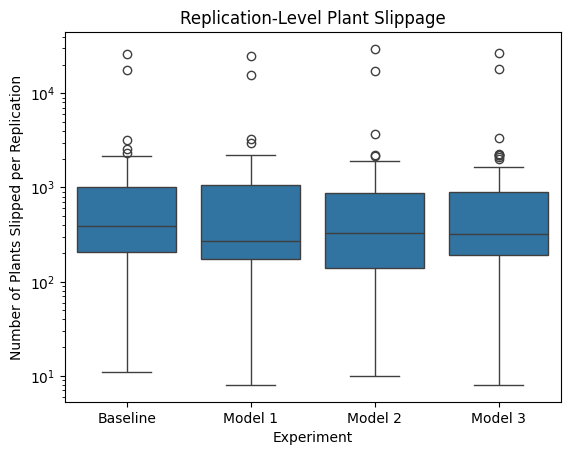

In [24]:
# TODO: Get summary numbers - quartiles etc here

sns.boxplot(total_slippage, x='experiment', y='num_plants_slipped')
plt.yscale('log')

plt.ylabel('Number of Plants Slipped per Replication')
plt.xlabel('Experiment')
plt.title('Replication-Level Plant Slippage')

/Users/robinms1/anaconda3/lib/python3.10/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


Text(0.5, 1.0, 'Replication-Level Plant Slippage')

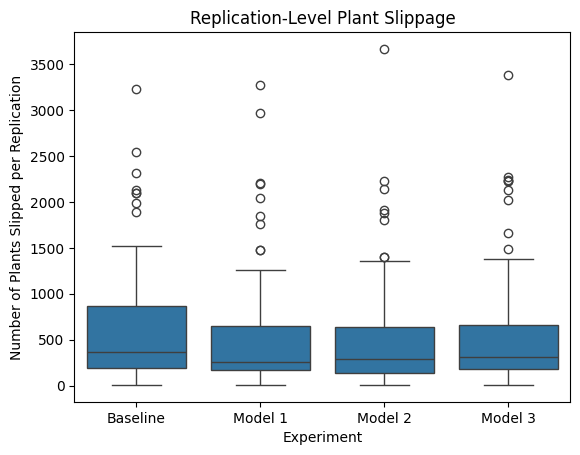

In [31]:
# Reducing to <10k slippage
sns.boxplot(total_slippage[total_slippage['num_plants_slipped'] < 1e4], x='experiment', y='num_plants_slipped')
#plt.yscale('log')

plt.ylabel('Number of Plants Slipped per Replication')
plt.xlabel('Experiment')
plt.title('Replication-Level Plant Slippage')

Text(0.5, 0, 'log Plants Slipped')

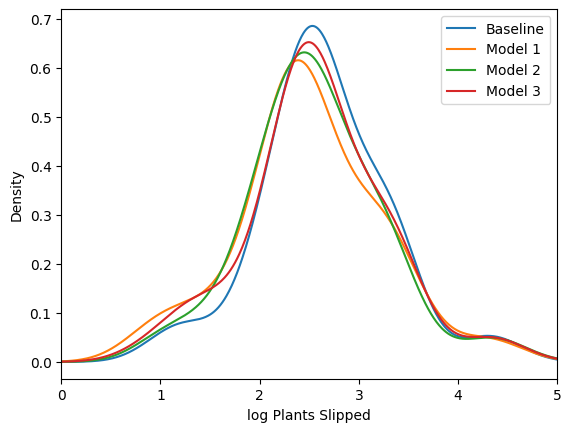

In [67]:
total_slippage['log num_plants_slipped'] = np.log10(total_slippage['num_plants_slipped'])

total_slippage.groupby('experiment')['log num_plants_slipped'].plot(kind='kde')
plt.legend()

plt.xlim([0, 5])
plt.xlabel('log Plants Slipped')

In [18]:
# Total inspected sample units across all replications
n_inspected_sample_units.groupby('experiment')['inspected_sample_units'].sum()

experiment
Baseline     975350
Model 1     1613700
Model 2     1584400
Model 3     1571500
Name: inspected_sample_units, dtype: int64

In [68]:
# Why are these all the same? -- as expected
replication_samples = n_inspected_sample_units.groupby(['experiment', 'replication'])['inspected_sample_units'].sum()
replication_samples

experiment  replication
Baseline    rep_0          19507
            rep_1          19507
            rep_10         19507
            rep_11         19507
            rep_12         19507
                           ...  
Model 3     rep_5          31430
            rep_6          31430
            rep_7          31430
            rep_8          31430
            rep_9          31430
Name: inspected_sample_units, Length: 200, dtype: int64

In [71]:
combined_results = replication_samples.reset_index().merge(total_slippage, on=['experiment', 'replication'])
combined_results

,experiment,replication,inspected_sample_units,num_plants_slipped,log num_plants_slipped
0,Baseline,rep_0,19507,941,2.973590
1,Baseline,rep_1,19507,546,2.737193
2,Baseline,rep_10,19507,349,2.542825
3,Baseline,rep_11,19507,352,2.546543
4,Baseline,rep_12,19507,289,2.460898
...,...,...,...,...,...
195,Model 3,rep_5,31430,370,2.568202
196,Model 3,rep_6,31430,89,1.949390
197,Model 3,rep_7,31430,232,2.365488
198,Model 3,rep_8,31430,8,0.903090


Text(0.5, 1.0, 'Plant Slippage vs Inspected Sample Units, Replication-Level')

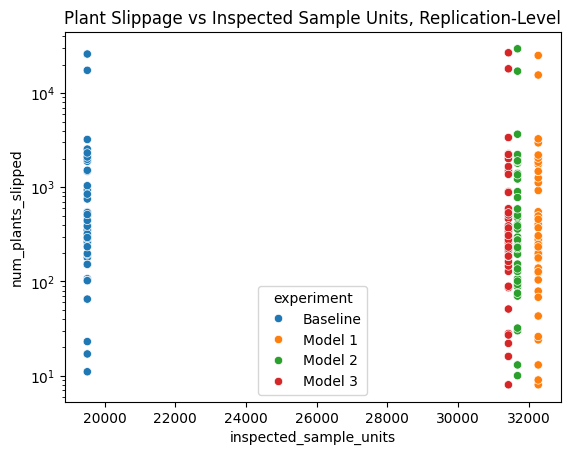

In [88]:
sns.scatterplot(combined_results, x='inspected_sample_units', y='num_plants_slipped', hue='experiment')
plt.yscale('log')

plt.title('Plant Slippage vs Inspected Sample Units, Replication-Level')

#plt.xlim(left=0)

Text(0, 0.5, '# Plants Slipped')

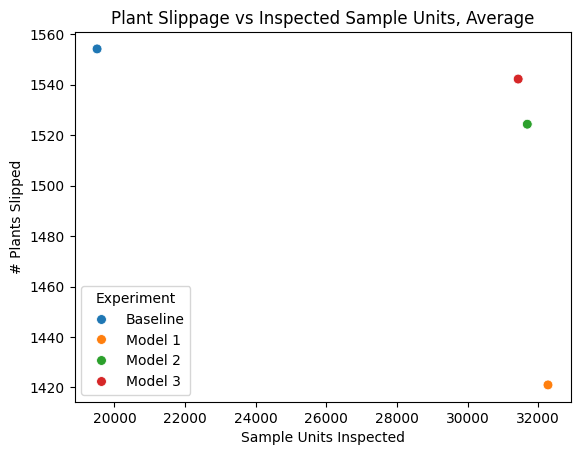

In [115]:
mean_combined_results = combined_results.groupby('experiment')[['inspected_sample_units', 'num_plants_slipped']].mean()

sns.scatterplot(mean_combined_results, x='inspected_sample_units', y='num_plants_slipped', hue='experiment', s=50)
#plt.yscale('log')
plt.title('Plant Slippage vs Inspected Sample Units, Average')
# add poisson +/- st dev
#plt.ylim(bottom=0)
plt.legend(title='Experiment')
plt.xlabel('Sample Units Inspected')
plt.ylabel('# Plants Slipped')

In [106]:
mean_combined_results

,inspected_sample_units,num_plants_slipped
experiment,,
Baseline,19507.0,1554.20
Model 1,32274.0,1421.02
Model 2,31688.0,1524.36
Model 3,31430.0,1542.26


In [103]:
std_combined_results = combined_results.groupby('experiment')[['inspected_sample_units', 'num_plants_slipped']].std() / np.sqrt(50)

In [116]:
std_combined_results

,inspected_sample_units,num_plants_slipped
experiment,,
Baseline,0.0,611.764498
Model 1,0.0,580.331809
Model 2,0.0,669.608801
Model 3,0.0,633.746504


Text(0, 0.5, '# Plants Slipped')

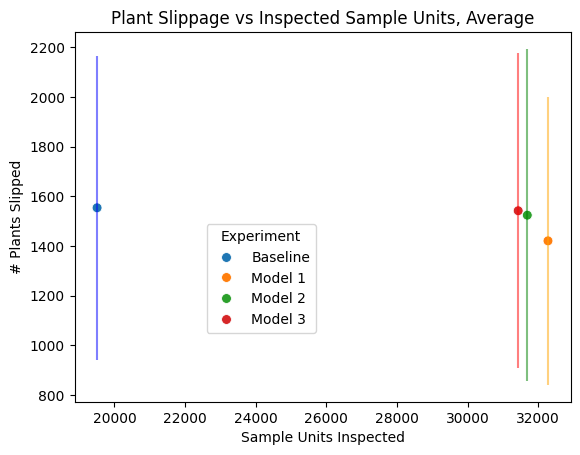

In [123]:
sns.scatterplot(mean_combined_results, x='inspected_sample_units', y='num_plants_slipped', hue='experiment', s=50)

plt.errorbar(x=mean_combined_results['inspected_sample_units'], y=mean_combined_results['num_plants_slipped'], yerr=std_combined_results['num_plants_slipped'], ecolor=['blue', 'orange', 'green', 'red'], alpha=0.5, linestyle='')

#plt.yscale('log')
plt.title('Plant Slippage vs Inspected Sample Units, Average')
# add poisson +/- st dev
#plt.ylim(bottom=0)
plt.legend(title='Experiment', bbox_to_anchor=[0.5, 0.5])
plt.xlabel('Sample Units Inspected')
plt.ylabel('# Plants Slipped')

Testing

In [38]:
# One-way ANOVA - are any of the provided distributions statistically different from the others?
# Like a multidistributional analog of two-sample t-tests

all_slippages = [total_slippage[total_slippage['experiment'] == exp]['num_plants_slipped'].values for exp in total_slippage['experiment'].unique()]
f_oneway(*all_slippages)

F_onewayResult(statistic=0.009495439029248915, pvalue=0.9987274802227605)

In [56]:
experiment_labels = ['Baseline', 'Model 1', 'Model 2', 'Model 3']
    
def run_paired_ttests(total_slippage, experiment_labels):
    result_outputs = pd.DataFrame()

    k = 0
    for i in range(len(experiment_labels)):
        for j in range(i+1, len(experiment_labels)):
            k += 1
            exp1 = experiment_labels[i]
            exp2 = experiment_labels[j]


            exp1_slippage = total_slippage[total_slippage['experiment'] == exp1].sort_values('replication')['num_plants_slipped']
            exp2_slippage = total_slippage[total_slippage['experiment'] == exp2].sort_values('replication')['num_plants_slipped']

            t_stat, p_val = ttest_rel(exp1_slippage, exp2_slippage)

            res = pd.DataFrame({'Experiment 1': exp1,
            'Experiment 2': exp2,
            't-statistic': t_stat,
            'p-value': p_val}, index=[k])

            result_outputs = pd.concat([result_outputs, res])
            
    return result_outputs

In [58]:
# TODO: grab this
run_paired_ttests(total_slippage, experiment_labels=['Baseline', 'Model 1', 'Model 2', 'Model 3'])

,Experiment 1,Experiment 2,t-statistic,p-value
1,Baseline,Model 1,2.806506,0.007166
2,Baseline,Model 2,0.364642,0.716948
3,Baseline,Model 3,0.347646,0.729595
4,Model 1,Model 2,-1.009312,0.317783
5,Model 1,Model 3,-1.847999,0.070643
6,Model 2,Model 3,-0.274492,0.784860


In [60]:
0.05/6 # conservative Bonferroni corrected cutoff - pair 1 statistically significant

0.008333333333333333

In [ ]:
# pull averages, rates of slippage, sampling

In [94]:
agg_results = df_results.groupby(['experiment', 'replication'])[['num_plants_slipped', 'num_plants', 'inspected_sample_units', 'num_sample_units']].sum()
agg_results

num_plants_slipped  num_plants  \
experiment replication                                   
Baseline   rep_0                       941   298872215   
           rep_1                       546   298872215   
           rep_10                      349   298872215   
           rep_11                      352   298872215   
           rep_12                      289   298872215   
...                                    ...         ...   
Model 3    rep_5                       370   298872215   
           rep_6                        89   298872215   
           rep_7                       232   298872215   
           rep_8                         8   298872215   
           rep_9                       308   298872215   

                        inspected_sample_units  num_sample_units  
experiment replication                                            
Baseline   rep_0                         19507            872667  
           rep_1                         19507            872667  
           rep_10                        19507            872667  
           rep_11                        19507            872667  
           rep_12                        19507            872667  
...                                        ...               ...  
Model 3    rep_5                         31430            872667  
           rep_6                         31430            872667  
           rep_7                         31430            872667  
           rep_8                         31430            872667  
           rep_9                         31430            872667  

[200 rows x 4 columns]

In [96]:
agg_results['prop_slipped'] = agg_results['num_plants_slipped'] / agg_results['num_plants']
agg_results['prop_sampled'] = agg_results['inspected_sample_units'] / agg_results['num_sample_units']
agg_results

num_plants_slipped  num_plants  \
experiment replication                                   
Baseline   rep_0                       941   298872215   
           rep_1                       546   298872215   
           rep_10                      349   298872215   
           rep_11                      352   298872215   
           rep_12                      289   298872215   
...                                    ...         ...   
Model 3    rep_5                       370   298872215   
           rep_6                        89   298872215   
           rep_7                       232   298872215   
           rep_8                         8   298872215   
           rep_9                       308   298872215   

                        inspected_sample_units  num_sample_units  \
experiment replication                                             
Baseline   rep_0                         19507            872667   
           rep_1                         19507            872667   
           rep_10                        19507            872667   
           rep_11                        19507            872667   
           rep_12                        19507            872667   
...                                        ...               ...   
Model 3    rep_5                         31430            872667   
           rep_6                         31430            872667   
           rep_7                         31430            872667   
           rep_8                         31430            872667   
           rep_9                         31430            872667   

                        prop_slipped  prop_sampled  
experiment replication                              
Baseline   rep_0        3.148503e-06      0.022353  
           rep_1        1.826868e-06      0.022353  
           rep_10       1.167723e-06      0.022353  
           rep_11       1.177761e-06      0.022353  
           rep_12       9.669684e-07      0.022353  
...                              ...           ...  
Model 3    rep_5        1.237987e-06      0.036016  
           rep_6        2.977861e-07      0.036016  
           rep_7        7.762515e-07      0.036016  
           rep_8        2.676729e-08      0.036016  
           rep_9        1.030541e-06      0.036016  

[200 rows x 6 columns]

Text(0.5, 1.0, 'Plant Slippage vs Inspected Sample Units, Replication-Level')

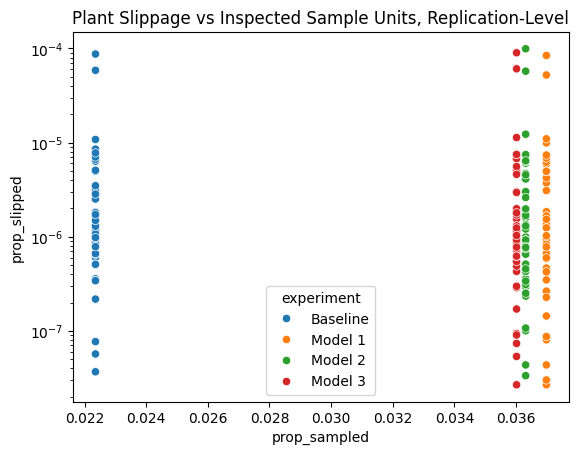

In [98]:
sns.scatterplot(agg_results, x='prop_sampled', y='prop_slipped', hue='experiment')
plt.yscale('log')

plt.title('Plant Slippage vs Inspected Sample Units, Replication-Level')

In [61]:
def calculate_slippage_metrics(df, experiment_labels=['high', 'low']):
    '''
    
    -- UNDER CONSTRUCTION -- 
    Given experiment data, calculate metrics for slippage
    
    Metrics to pull: 
    - Total slippage (plants) per replication
    - - Total intercepted plants per replication
    - Total slipped sample units per replication
    - Mean inspected sample units per inspection number (per replication)
    - Total plants inspected (etc.)
    '''
    
    df['num_plants_slipped'] = df['missed'].astype(int) * df['infected_plants']
    df['prop_inspected'] = df['inspected_sample_units'] / df['num_plants']
    
    # Collect aggregate stats - per replication, per experiment
    
    # Plant-unit slippage
    total_slippage = df.groupby(['experiment', 'replication'])['num_plants_slipped'].sum().reset_index()
    
    
    # Number of inspected sample units per 
    
    
    n_inspected_sample_units = df.groupby(['experiment', 'replication', 'inspection_number'])['inspected_sample_units'].sum().reset_index()
    mean_inspected_sample_units = n_inspected_sample_units.groupby(['experiment', 'replication'])['inspected_sample_units'].mean().reset_index()

    
    print(total_slippage)
    
    ## Slippage metrics

    ## Testing - check that only 2 experiments selected
    # Total slippage
    total_slippage0 = total_slippage[total_slippage['experiment'] == experiment_labels[0]]
    total_slippage1 = total_slippage[total_slippage['experiment'] == experiment_labels[1]]
    
    
    # Run two-sample t-test
    total_slippage_2stt = ttest_ind(total_slippage0['num_plants_slipped'], total_slippage1['num_plants_slipped'])
    
    
    # Run paired t-test
    total_slippage_ptt = ttest_rel(total_slippage0['num_plants_slipped'], total_slippage1['num_plants_slipped'])
    
    
    print(total_slippage_2stt)
    
    print(total_slippage_ptt)

In [62]:
calculate_slippage_metrics(df_results)

    experiment replication  num_plants_slipped
0     Baseline       rep_0                 941
1     Baseline       rep_1                 546
2     Baseline      rep_10                 349
3     Baseline      rep_11                 352
4     Baseline      rep_12                 289
..         ...         ...                 ...
195    Model 3       rep_5                 370
196    Model 3       rep_6                  89
197    Model 3       rep_7                 232
198    Model 3       rep_8                   8
199    Model 3       rep_9                 308

[200 rows x 3 columns]
Ttest_indResult(statistic=nan, pvalue=nan)
TtestResult(statistic=nan, pvalue=nan, df=nan)


In [193]:
df_paired = pd.pivot_table(total_slippage[total_slippage['experiment'].isin(['Baseline', 'Model 1'])], 
               values='num_plants_slipped', index='replication', columns='experiment')
df_paired.head()            

experiment,Baseline,Model 1
replication,,
rep_0,941.0,925.0
rep_1,546.0,385.0
rep_10,349.0,406.0
rep_11,352.0,175.0
rep_12,289.0,259.0


In [143]:
symlogbins = [-1e4, -3e3, -1e3, -3e2, -1e2, -3e1, -1e1, -1, 0, 1, 1e1, 3e1, 1e2, 3e2, 1e3, 3e3, 1e4]

Text(0.5, 1.0, 'Paired Replication-Level Slippage: Model 1 vs Baseline')

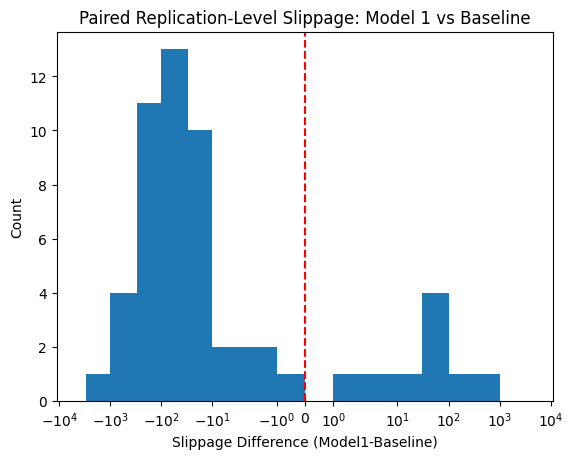

In [145]:
df_paired['Difference'] = df_paired['Model 1'] - df_paired['Baseline']

df_paired['Difference'].hist(bins=symlogbins, grid=False)
plt.ylabel('Count')
plt.xlabel('Slippage Difference (Model1-Baseline)')
plt.axvline(0, c='r', linestyle='--')
plt.xscale('symlog')

plt.title('Paired Replication-Level Slippage: Model 1 vs Baseline')

Text(0.5, 1.0, 'Model 1 vs Baseline Slippage by Replication')

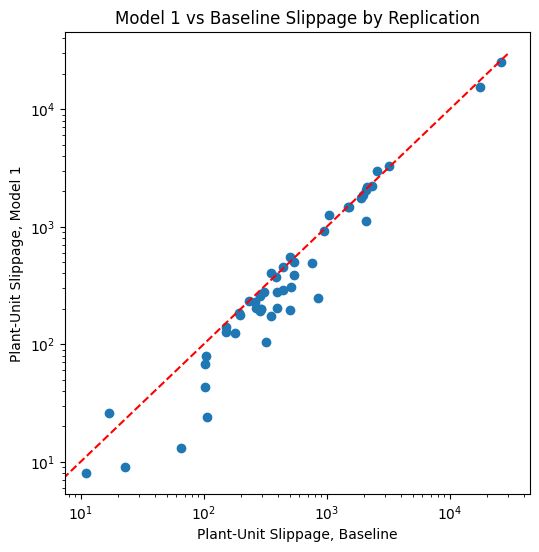

In [176]:
plt.figure(figsize=[6, 6])
xs = np.linspace(0, 30000, 10)
plt.scatter(df_paired['Baseline'], df_paired['Model 1'])
plt.plot(xs, xs, c='red', linestyle='--')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Plant-Unit Slippage, Baseline')
plt.ylabel('Plant-Unit Slippage, Model 1')

plt.title('Model 1 vs Baseline Slippage by Replication')

In [147]:
# Number of replications where model 1 outperforms baseline
len(df_paired[df_paired['Difference'] < 0])

42

Model 2 vs baseline

Text(0.5, 1.0, 'Paired Replication-Level Slippage: Model 2 vs Baseline')

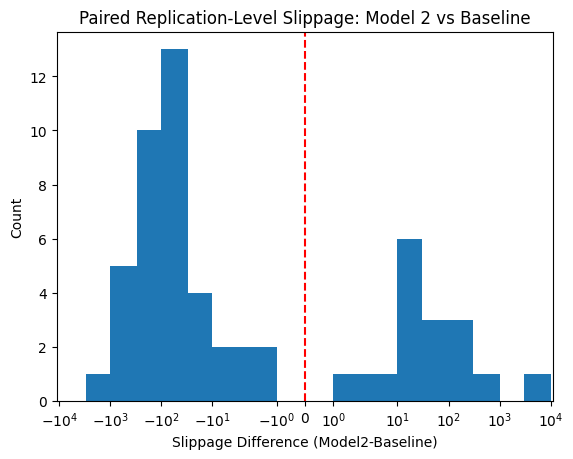

In [186]:
df_paired2 = pd.pivot_table(total_slippage[total_slippage['experiment'].isin(['Baseline', 'Model 2'])], 
               values='num_plants_slipped', index='replication', columns='experiment')

df_paired2['Difference'] = df_paired2['Model 2'] - df_paired2['Baseline']


df_paired2['Difference'].hist(bins=symlogbins, grid=False)
plt.ylabel('Count')
plt.xlabel('Slippage Difference (Model2-Baseline)')
plt.axvline(0, c='r', linestyle='--')
plt.xscale('symlog')

plt.title('Paired Replication-Level Slippage: Model 2 vs Baseline')     

Text(0.5, 1.0, 'Model 2 vs Baseline Slippage by Replication')

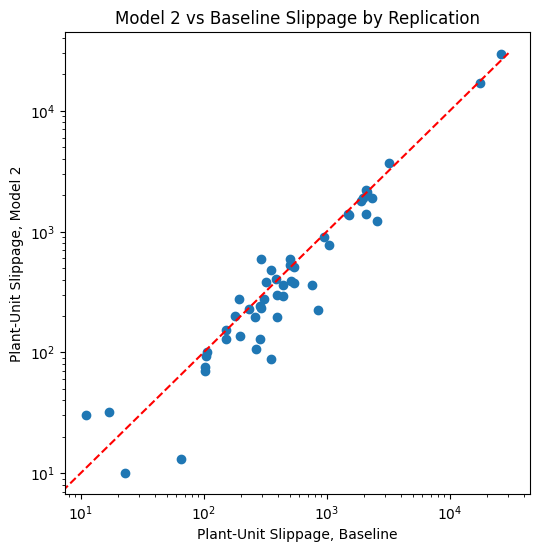

In [179]:
plt.figure(figsize=[6, 6])
xs = np.linspace(0, 30000, 10)
plt.scatter(df_paired2['Baseline'], df_paired2['Model 2'])
plt.plot(xs, xs, c='red', linestyle='--')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Plant-Unit Slippage, Baseline')
plt.ylabel('Plant-Unit Slippage, Model 2')

plt.title('Model 2 vs Baseline Slippage by Replication')

In [185]:
len(df_paired2[df_paired2['Difference'] < 0])

35

Model 3 vs baseline

Text(0.5, 1.0, 'Paired Replication-Level Slippage: Model 3 vs Baseline')

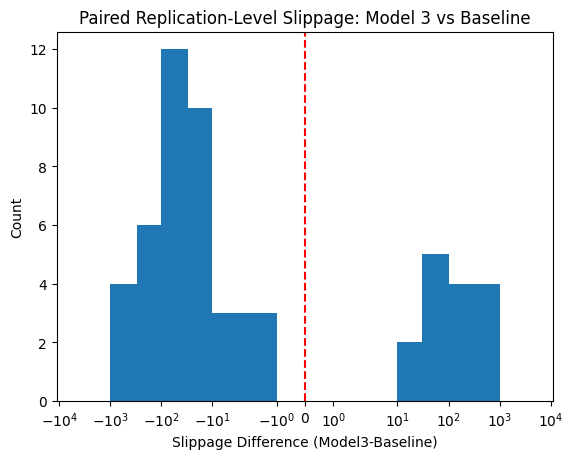

In [187]:
df_paired3 = pd.pivot_table(total_slippage[total_slippage['experiment'].isin(['Baseline', 'Model 3'])], 
               values='num_plants_slipped', index='replication', columns='experiment')

df_paired3['Difference'] = df_paired3['Model 3'] - df_paired3['Baseline']


df_paired3['Difference'].hist(bins=symlogbins, grid=False)
plt.ylabel('Count')
plt.xlabel('Slippage Difference (Model3-Baseline)')
plt.axvline(0, c='r', linestyle='--')
plt.xscale('symlog')

plt.title('Paired Replication-Level Slippage: Model 3 vs Baseline') 

Text(0.5, 1.0, 'Model 3 vs Baseline Slippage by Replication')

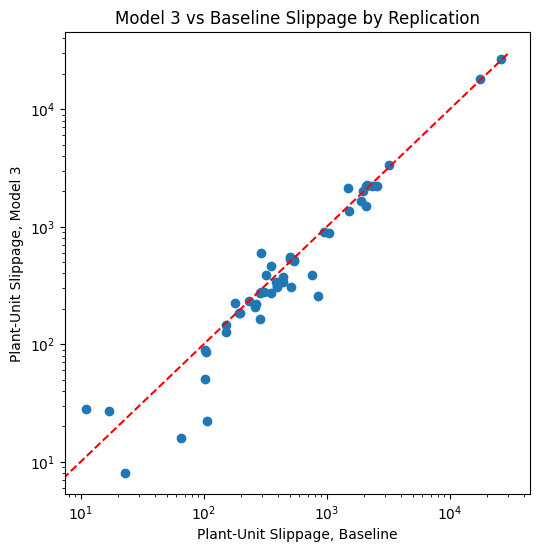

In [183]:
plt.figure(figsize=[6, 6])
xs = np.linspace(0, 30000, 10)
plt.scatter(df_paired3['Baseline'], df_paired3['Model 3'])
plt.plot(xs, xs, c='red', linestyle='--')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Plant-Unit Slippage, Baseline')
plt.ylabel('Plant-Unit Slippage, Model 3')

plt.title('Model 3 vs Baseline Slippage by Replication')

In [184]:
len(df_paired3[df_paired3['Difference'] < 0])

35

Sample units per consignment inspected

In [191]:
exp_units = df_results.groupby(['experiment', 'replication', 'inspection_number'])['inspected_sample_units'].sum().reset_index()
exp_inspected = exp_units.groupby(['experiment', 'replication'])['inspected_sample_units'].mean()


In [192]:
combined_results_full = combined_results.merge(exp_inspected.reset_index().rename(columns={'inspected_sample_units': 'inspected_sample_units_per_consignment'}))
combined_results_full

,experiment,replication,inspected_sample_units,num_plants_slipped,log num_plants_slipped,inspected_sample_units_per_consignment
0,Baseline,rep_0,19507,941,2.973590,6.502333
1,Baseline,rep_1,19507,546,2.737193,6.502333
2,Baseline,rep_10,19507,349,2.542825,6.502333
3,Baseline,rep_11,19507,352,2.546543,6.502333
4,Baseline,rep_12,19507,289,2.460898,6.502333
...,...,...,...,...,...,...
195,Model 3,rep_5,31430,370,2.568202,10.476667
196,Model 3,rep_6,31430,89,1.949390,10.476667
197,Model 3,rep_7,31430,232,2.365488,10.476667
198,Model 3,rep_8,31430,8,0.903090,10.476667


Text(0, 0.5, '# Plants Slipped')

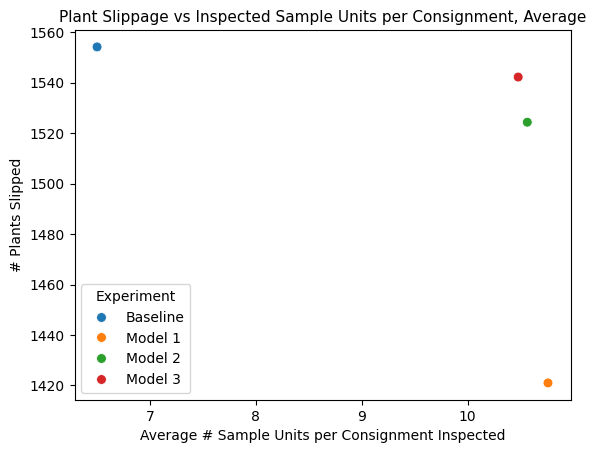

In [190]:
mean_combined_results_consign = combined_results_full.groupby('experiment')[['inspected_sample_units_per_consignment', 'num_plants_slipped']].mean()

sns.scatterplot(mean_combined_results_consign, x='inspected_sample_units_per_consignment', y='num_plants_slipped', hue='experiment', s=50)
#plt.yscale('log')
plt.title('Plant Slippage vs Inspected Sample Units per Consignment, Average', fontsize=11)
# add poisson +/- st dev
#plt.ylim(bottom=0)
plt.legend(title='Experiment')
plt.xlabel('Average # Sample Units per Consignment Inspected')
plt.ylabel('# Plants Slipped')

Data to save

In [168]:
combined_results_full.to_csv('replication-level_slippage-workload_04222026.csv')